In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [19]:
# Load the data
config = pd.read_csv('experiments/models/dataset_size/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_size.csv')

In [20]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [21]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [22]:
df = df[(df['train_size'] == 0.9) & (df['val_size'] == 0.1)]

In [23]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

In [ ]:
df

/tmp/ipykernel_863703/952146440.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')


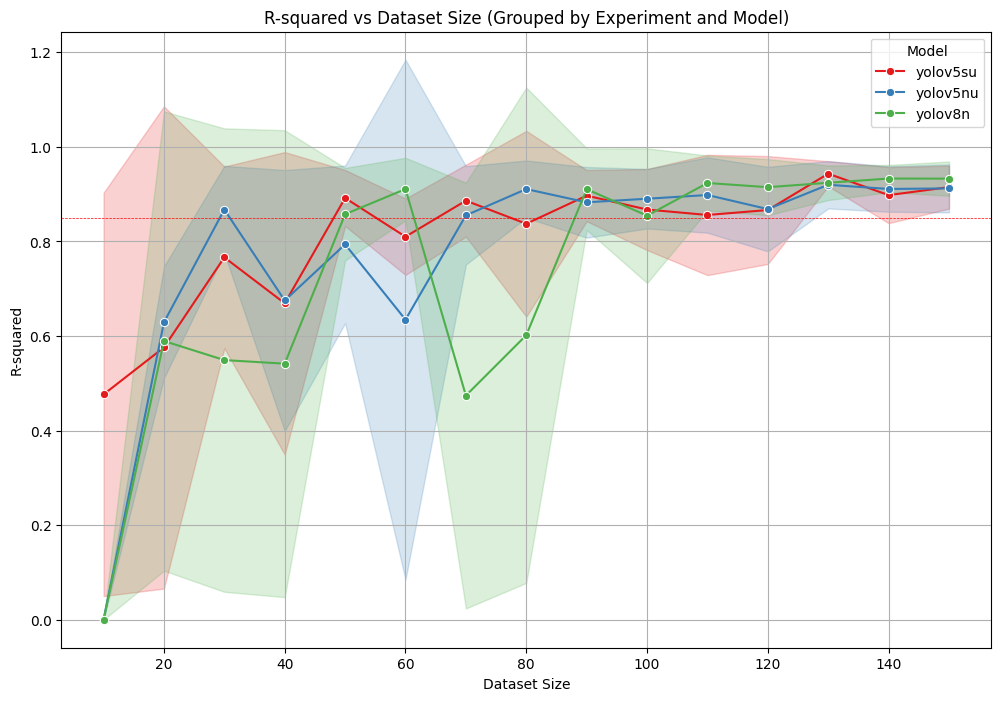

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov5nu', 'yolov5su'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', data=filtered_df, ci='sd', estimator='mean', marker='o', palette='Set1')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

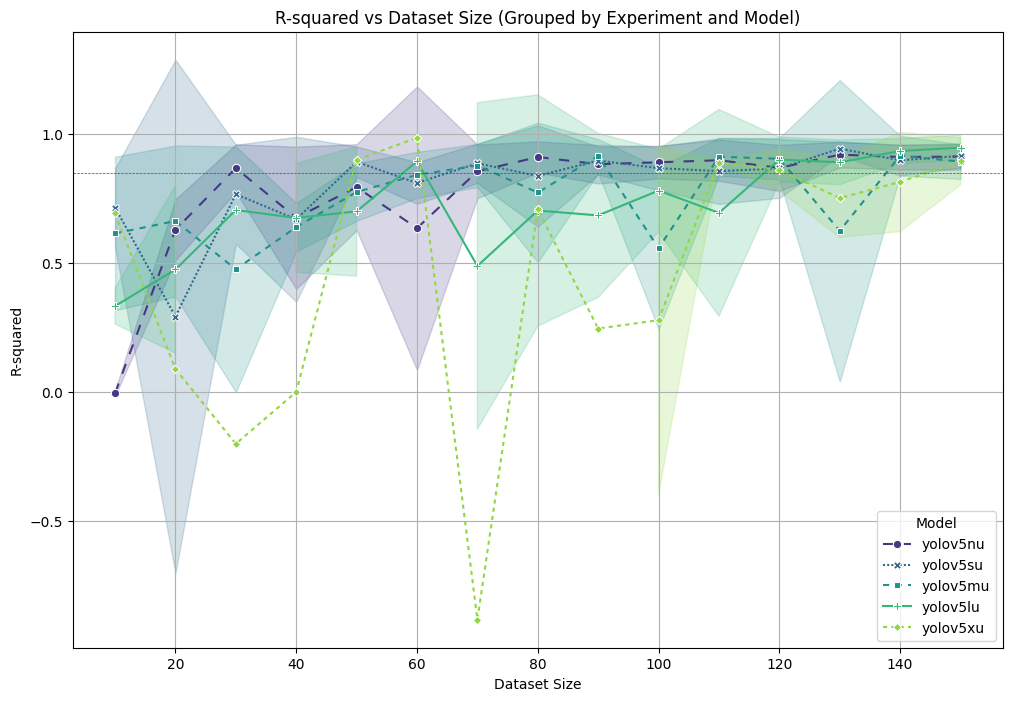

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov5lu': '', 'yolov5nu': (5, 5), 'yolov5su': (1, 1), 'yolov5mu': (3, 3), 'yolov5xu': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'], style_order=['yolov5nu', 'yolov5su', 'yolov5mu', 'yolov5lu', 'yolov5xu'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

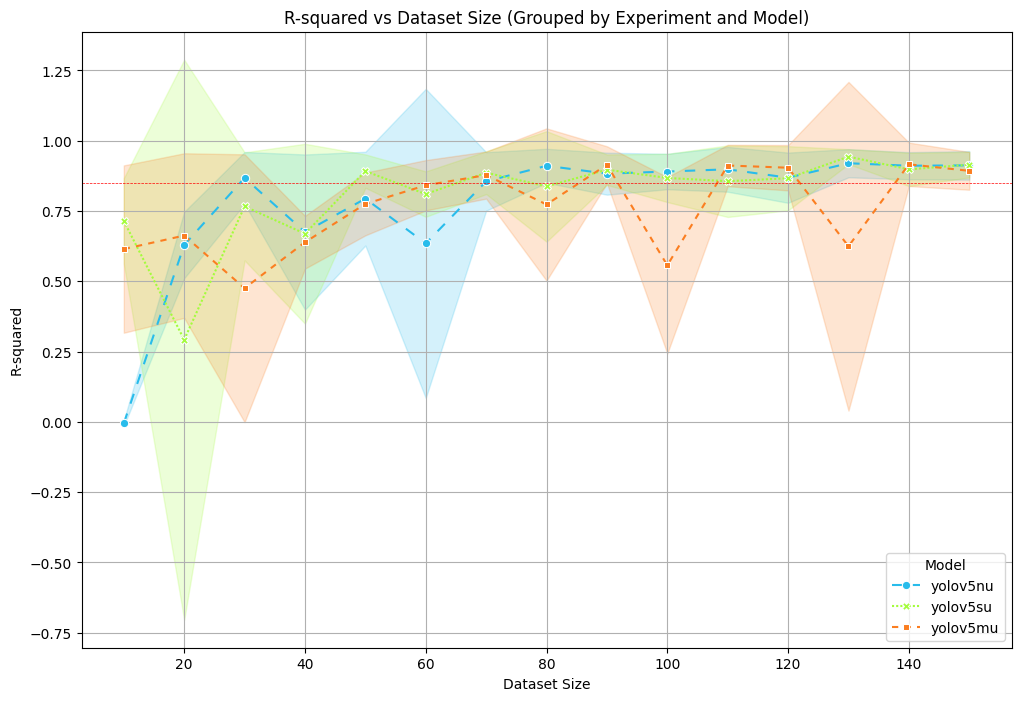

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov5n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov5nu', 'yolov5su', 'yolov5mu'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = { 'yolov5nu': (5, 5), 'yolov5su': (1, 1), 'yolov5mu': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov5nu', 'yolov5su', 'yolov5mu'], style_order=['yolov5nu', 'yolov5su', 'yolov5mu'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

177


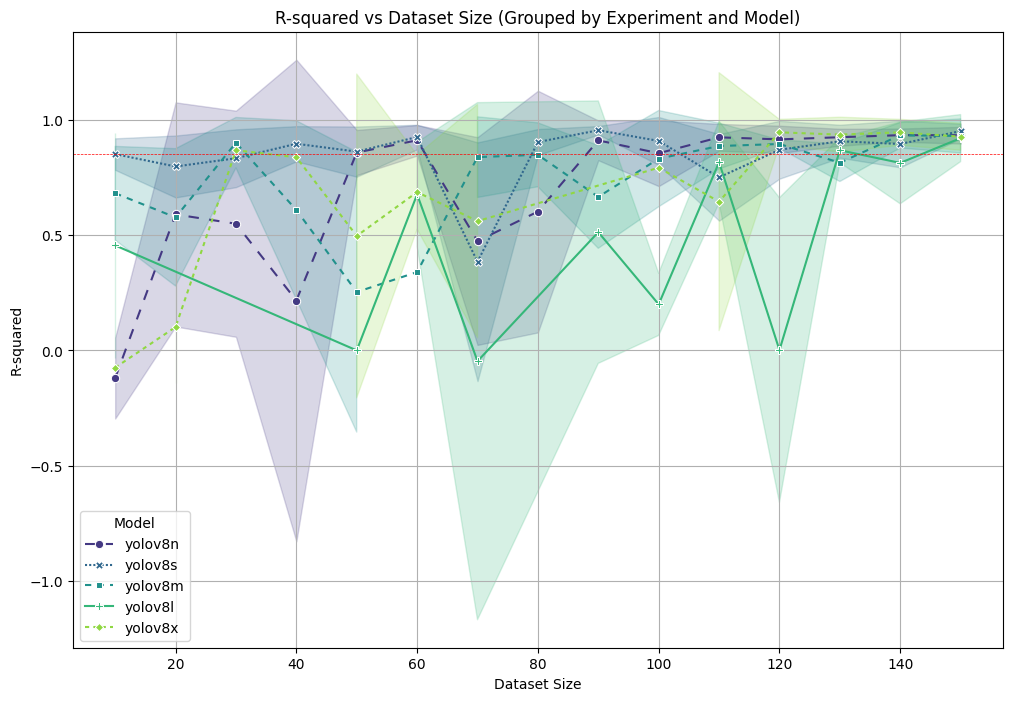

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov8n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolov8l': '', 'yolov8n': (5, 5), 'yolov8s': (1, 1), 'yolov8m': (3, 3), 'yolov8x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'], style_order=['yolov8n', 'yolov8s', 'yolov8m', 'yolov8l', 'yolov8x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

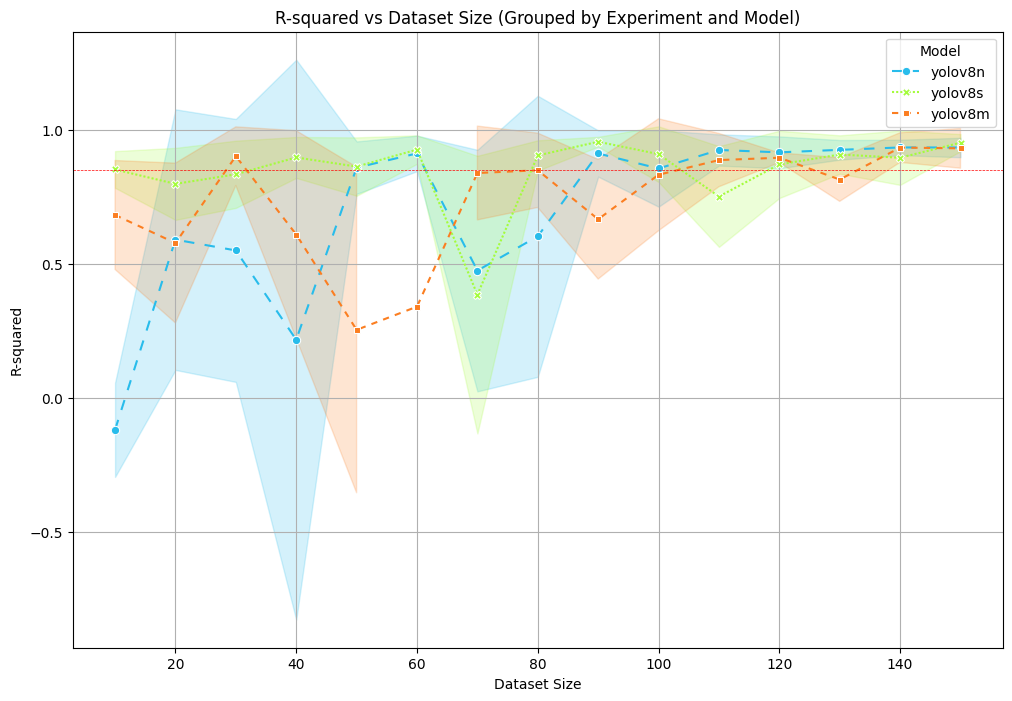

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolov8n and yolov8n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolov8n', 'yolov8s', 'yolov8m'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = {'yolov8n': (5, 5), 'yolov8s': (1, 1), 'yolov8m': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolov8n', 'yolov8s', 'yolov8m'], style_order=['yolov8n', 'yolov8s', 'yolov8m'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

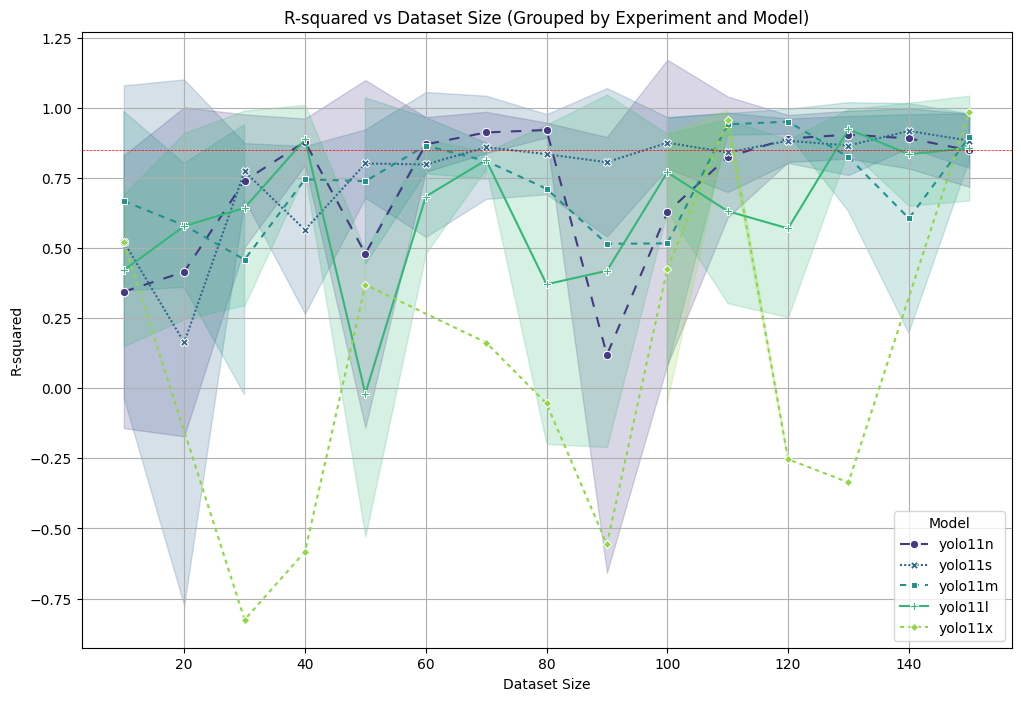

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolo11n and yolo11n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'yolo11l': '', 'yolo11n': (5, 5), 'yolo11s': (1, 1), 'yolo11m': (3, 3), 'yolo11x': (2, 2)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'], style_order=['yolo11n', 'yolo11s', 'yolo11m', 'yolo11l', 'yolo11x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

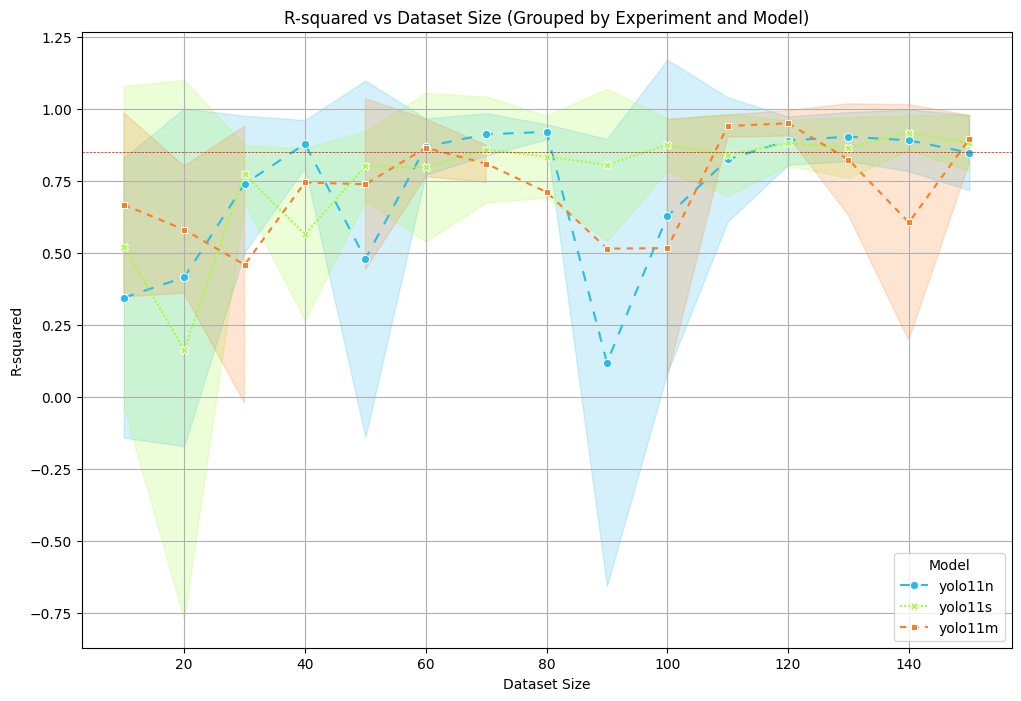

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both yolo11n and yolo11n models
filtered_df = filtered_df[filtered_df['model'].isin(['yolo11n', 'yolo11s', 'yolo11m'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("turbo", 3)  # Update palette to have 5 colors
linestyles = {'yolo11n': (5, 5), 'yolo11s': (1, 1), 'yolo11m': (3, 3)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['yolo11n', 'yolo11s', 'yolo11m'], style_order=['yolo11n', 'yolo11s', 'yolo11m'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

/tmp/ipykernel_29725/2899624212.py:32: UserWarning: The palette list has more values (5) than needed (2), which may not be intended.
  sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['rtdetr-l', 'rtdetr-x'], style_order=['rtdetr-l', 'rtdetr-x'])


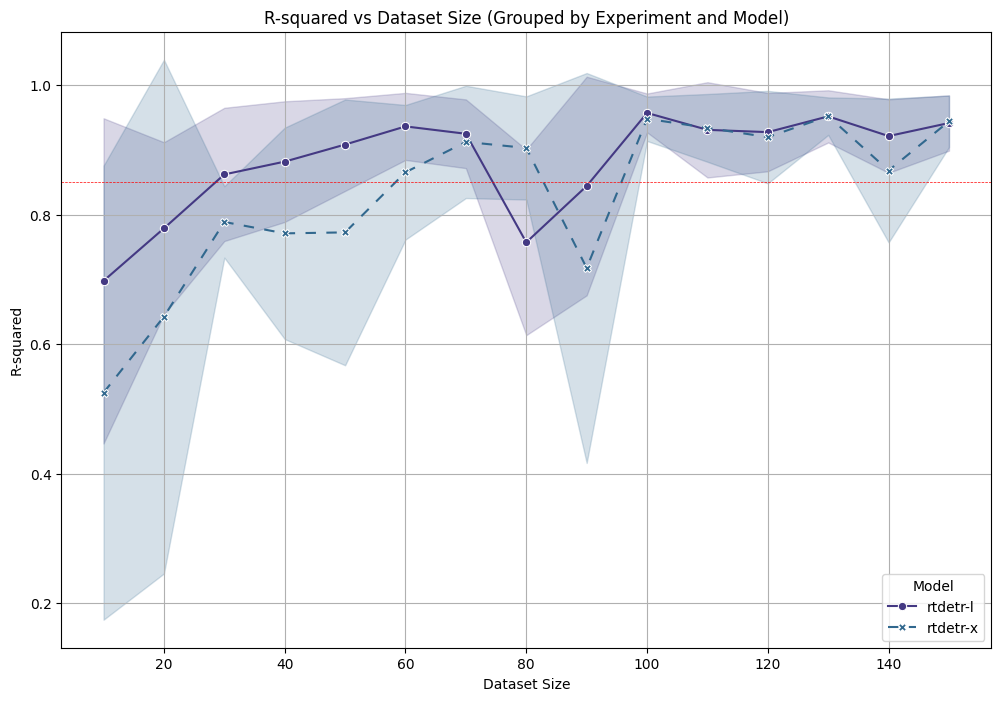

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()

# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)

# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(['rtdetr-l', 'rtdetr-x'])]

# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]

# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]

# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')

# Define custom colors and linestyles for each model
palette = sns.color_palette("viridis", 5)  # Update palette to have 5 colors
linestyles = {'rtdetr-l': '', 'rtdetr-x': (5, 5)}  # Update dashes to have 5 styles

# Create a line plot with 'dataset_size' on the x-axis and mean 'r_squared' on the y-axis, grouped by 'model'
plt.figure(figsize=(12, 8))
sns.lineplot(x='dataset_size', y='r_squared', hue='model', style='model', data=filtered_df, errorbar='sd', estimator='mean', markers=True, palette=palette, dashes=linestyles, hue_order=['rtdetr-l', 'rtdetr-x'], style_order=['rtdetr-l', 'rtdetr-x'])

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('Dataset Size')
plt.ylabel('R-squared')
plt.title('R-squared vs Dataset Size (Grouped by Experiment and Model)')
plt.grid(True)
plt.legend(title='Model')

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()
print(len(filtered_df))
# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)
print(len(filtered_df))
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Select out_domain aws no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']
print(len(filtered_df))
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(['rtdetr-l', 'rtdetr-x'])]
print(len(filtered_df))
# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]
print(len(filtered_df))
# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]
print(len(filtered_df))
# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']
print(len(filtered_df))
# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')
print(len(filtered_df))
# Define custom colors and linestyles for each model - only need 2 colors
palette = sns.color_palette("viridis", 2)  # Only 2 models
linestyles = {'rtdetr-l': '', 'rtdetr-x': (5, 5)}

# Create subplots
models = ['rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    # Filter to single model but don't use it for hue/style
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Simple lineplot without hue/style since we're already filtered
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',  # Use marker='o' instead of markers=True
        color=palette[models.index(model)],
        ax=ax
    )
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('R-squared')
    ax.grid(True)

plt.tight_layout()
plt.show()

7238
7238
Unique model values: ['yolov5su' 'yolov5nu' 'yolov8n' 'yolo11n' 'yolov5mu' 'yolov8m' 'yolo11m'
 'yolov5lu' 'yolov8l' 'yolo11l' 'yolov5xu' 'yolov8s' 'yolo11s' 'rtdetr-l'
 'rtdetr-x' 'yolov8x' 'yolo11x']
6034
Unique model values: ['yolov5su' 'yolov5nu' 'yolov8n' 'yolo11n' 'yolov5mu' 'yolov8m' 'yolo11m'
 'yolov5lu' 'yolov8l' 'yolo11l' 'yolov5xu' 'yolov8s' 'yolo11s' 'rtdetr-l'
 'rtdetr-x' 'yolov8x' 'yolo11x']
597
97
93
93
93


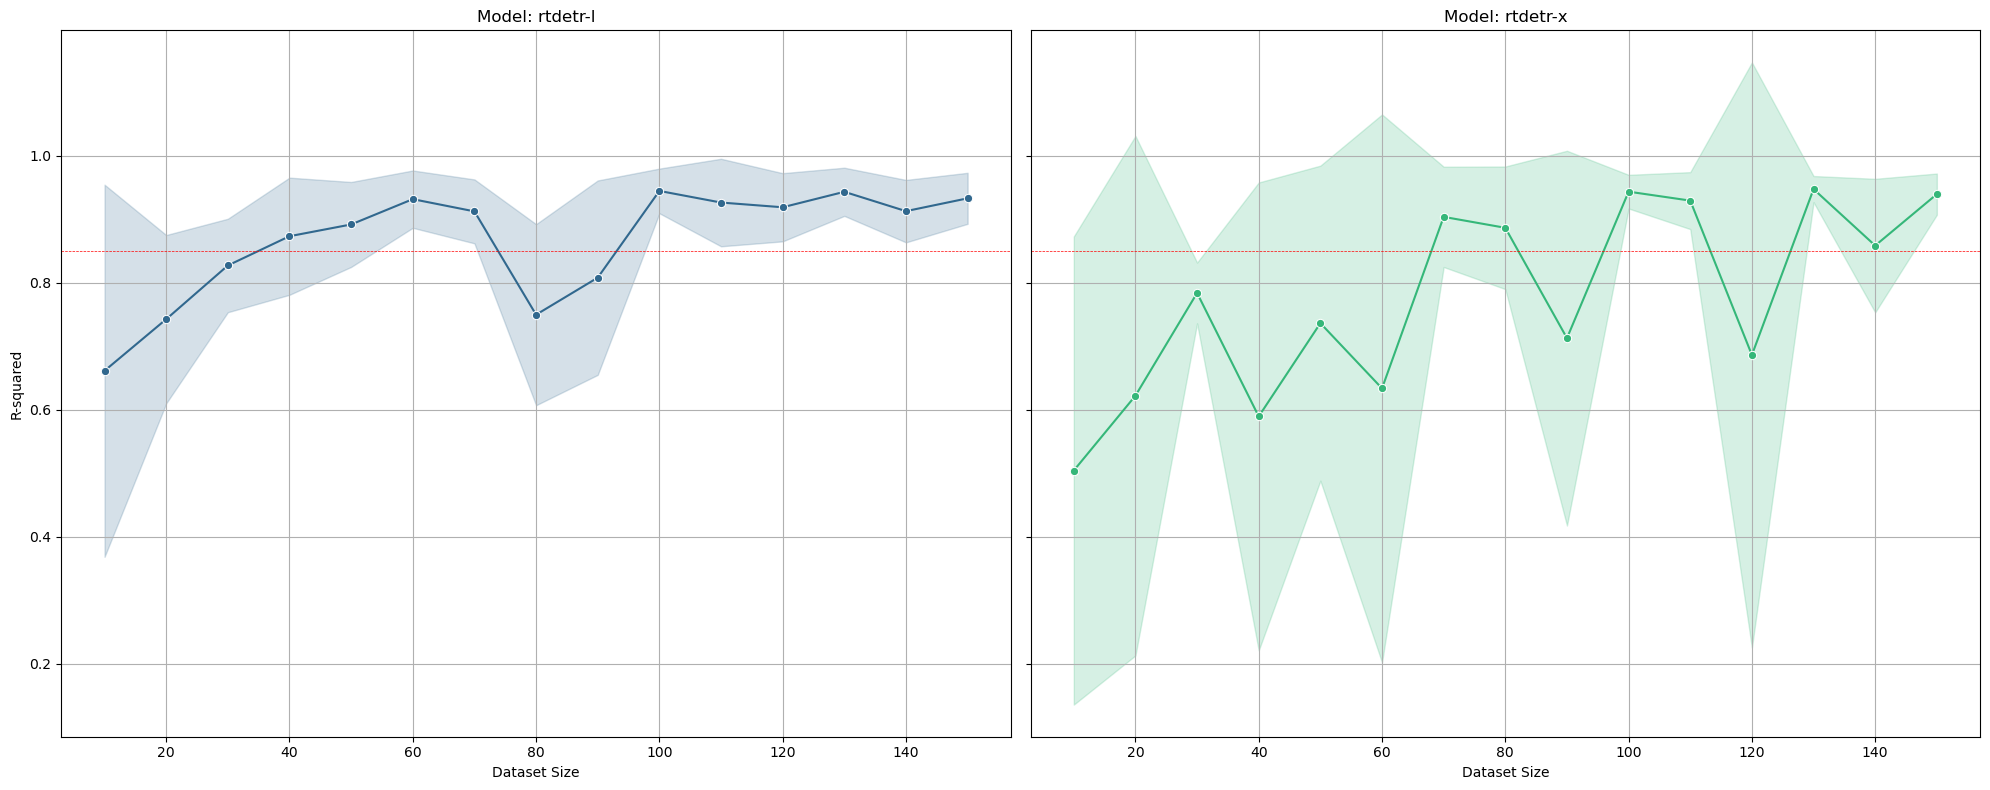

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the filtered DataFrame
filtered_df = df.copy()
print(len(filtered_df))
# Set NaN values in the 'r_squared' column to 0
filtered_df['r_squared'] = filtered_df['r_squared'].fillna(0)
print(len(filtered_df))
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Select out_domain aws no
filtered_df = filtered_df[filtered_df['out_domain'] == 'no']
print(len(filtered_df))
# Add this after the out_domain filter
print("Unique model values:", filtered_df['model'].unique())
# Filter the DataFrame to include both rtdetrn and rtdetrn models
filtered_df = filtered_df[filtered_df['model'].isin(['rtdetr-l', 'rtdetr-x'])]
print(len(filtered_df))
# Group by 'experiment' and 'model' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby(['experiment', 'model'])['r_squared'].idxmax()]
print(len(filtered_df))
# Set r-squared <0 to 0
filtered_df = filtered_df[filtered_df['r_squared'] >= -1]
print(len(filtered_df))
# Create a new column 'exp' with 'dataset_size'
filtered_df['exp'] = filtered_df['dataset_size']
print(len(filtered_df))
# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_size')
print(len(filtered_df))
# Define custom colors and linestyles for each model - only need 2 colors
palette = sns.color_palette("viridis", 2)  # Only 2 models
linestyles = {'rtdetr-l': '', 'rtdetr-x': (5, 5)}

# Create subplots
models = ['rtdetr-l', 'rtdetr-x']
fig, axes = plt.subplots(1, len(models), figsize=(20, 8), sharey=True)

for ax, model in zip(axes, models):
    # Filter to single model but don't use it for hue/style
    model_data = filtered_df[filtered_df['model'] == model]
    
    # Simple lineplot without hue/style since we're already filtered
    sns.lineplot(
        x='dataset_size', 
        y='r_squared', 
        data=model_data,
        errorbar='sd', 
        estimator='mean', 
        marker='o',  # Use marker='o' instead of markers=True
        color=palette[models.index(model)],
        ax=ax
    )
    
    ax.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)
    ax.set_title(f'Model: {model}')
    ax.set_xlabel('Dataset Size')
    ax.set_ylabel('R-squared')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
filtered_df

array(['yolov5su', 'yolov5nu', 'yolov8n', 'yolo11n', 'yolov5mu',
       'yolov8m', 'yolo11m', 'yolov5lu', 'yolov8l', 'yolo11l', 'yolov5xu',
       'yolov8s', 'yolo11s', 'yolov8x', 'yolo11x', 'rtdetr-l', 'rtdetr-x'],
      dtype=object)